# Grad-CAM Analysis of Borderline Predictions and High-Confidence Errors

This notebook investigates **how a fine-tuned MobileNetV2 makes binary defect
predictions on steel-surface images**. It focuses on two practically important
groups:

1. borderline predictions close to the decision threshold
   (`0.40 ≤ P(defect) ≤ 0.60`);
2. false positives and false negatives made with high confidence.

Grad-CAM is used to highlight image regions that contribute positively to
`P(defect)`. The heatmaps are explanatory signals, not pixel-level defect
segmentations.

**Dataset:** [Severstal Steel Defect Detection](https://www.kaggle.com/competitions/severstal-steel-defect-detection)  
**Architecture:** MobileNetV2, input size `128 × 800`, binary sigmoid output  
**Decision threshold:** `0.50`

> **Reproducibility and checkpoint note**
>
> The displayed results reproduce the case study used in the thesis and were
> generated in Google Colab with TensorFlow 2.20 and the saved thesis checkpoint
> `mobilenetv2_wide_finetuned_final.keras`. The training pipeline was later
> rerun and the repository's current checkpoint was updated as
> `mobilenetv2_finetuned.keras`.
>
> The notebook therefore keeps the thesis checkpoint as its default experiment
> so that its stored probabilities, error counts, selected image IDs, and
> Grad-CAM figures refer to one consistent model. To analyze the current
> repository checkpoint, change the checkpoint option below and rerun all cells;
> the resulting metrics and representative cases must then be treated as a new
> experiment rather than mixed with the embedded thesis results.


## 1. Environment and project paths

The notebook can be opened from the repository root, from the `notebooks`
directory, or directly in Google Colab. The path setup below keeps generated
artifacts inside `results/gradcam_error_analysis`.


In [ ]:
import getpass
import os
import random
import shutil
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
TRAIN_CSV_PATH = RAW_DATA_DIR / "train.csv"
TRAIN_IMAGES_DIR = RAW_DATA_DIR / "train_images"
RESULTS_DIR = PROJECT_ROOT / "results" / "gradcam_error_analysis"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (128, 800)
BATCH_SIZE = 16

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset preparation

The original competition annotations contain one row per defect mask. They are
converted into one binary label per image:

- `0` — No Defect
- `1` — at least one annotated defect

Before running the next cell, accept the competition rules on Kaggle. If the
dataset is not already available locally, provide a Kaggle API token when
prompted.


In [ ]:
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
dataset_archive = RAW_DATA_DIR / "severstal-steel-defect-detection.zip"

if not TRAIN_CSV_PATH.exists() or not TRAIN_IMAGES_DIR.exists():
    os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Paste your Kaggle API token: ")
    %pip install -q --upgrade kaggle

    if not dataset_archive.exists():
        !kaggle competitions download -c severstal-steel-defect-detection -p "{RAW_DATA_DIR}"

    with zipfile.ZipFile(dataset_archive) as archive:
        archive.extractall(RAW_DATA_DIR)

print("train.csv found:", TRAIN_CSV_PATH.exists())
print("train_images found:", TRAIN_IMAGES_DIR.exists())


In [ ]:
annotations = pd.read_csv(TRAIN_CSV_PATH)
defect_images = set(
    annotations.dropna(subset=["EncodedPixels"])["ImageId"].unique()
)
all_images = sorted(path.name for path in TRAIN_IMAGES_DIR.glob("*.jpg"))

binary_labels = pd.DataFrame({"ImageId": all_images})
binary_labels["HasDefect"] = (
    binary_labels["ImageId"].isin(defect_images).astype("int32")
)
binary_labels["ImagePath"] = binary_labels["ImageId"].map(
    lambda image_id: str(TRAIN_IMAGES_DIR / image_id)
)

labels_path = PROJECT_ROOT / "data" / "binary_labels.csv"
labels_path.parent.mkdir(parents=True, exist_ok=True)
binary_labels[["ImageId", "HasDefect"]].to_csv(labels_path, index=False)

print("Total images:", len(binary_labels))
print("\nLabel counts:")
print(binary_labels["HasDefect"].value_counts())
print("\nLabel percentages:")
print((binary_labels["HasDefect"].value_counts(normalize=True) * 100).round(2))


Total images: 12568

Label counts:
HasDefect
1    6666
0    5902

Label percentages:
HasDefect
1    53.04
0    46.96


### Stratified train/validation/test split

The same deterministic split used during model development is recreated with
`random_state=42`: 70% training, 15% validation, and 15% testing. Stratification
preserves the defect/no-defect ratio in every subset.


In [ ]:
train_df, temporary_df = train_test_split(
    binary_labels,
    test_size=0.30,
    stratify=binary_labels["HasDefect"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["HasDefect"],
    random_state=SEED,
)

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

for name, subset in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    distribution = subset["HasDefect"].value_counts(normalize=True).sort_index() * 100
    print(f"\n{name} label distribution (%):")
    print(distribution)


Train images: 8797
Validation images: 1885
Test images: 1886

Train label distribution (%):
HasDefect
0    46.959191
1    53.040809

Validation label distribution (%):
HasDefect
0    46.949602
1    53.050398

Test label distribution (%):
HasDefect
0    46.977731
1    53.022269


## 3. Test input pipeline

Images are resized to the wide `128 × 800` representation used during training
and normalized with MobileNetV2's `preprocess_input`. The test dataset is not
shuffled, so predictions remain aligned with `test_df`.


In [ ]:
def load_and_preprocess_image(filepath, label):
    image_tensor = tf.io.read_file(filepath)
    image_tensor = tf.image.decode_jpeg(image_tensor, channels=3)
    image_tensor = tf.image.resize(image_tensor, IMG_SIZE)
    image_tensor = preprocess_input(image_tensor)
    return image_tensor, label


test_paths = test_df["ImagePath"].to_numpy()
test_labels = test_df["HasDefect"].to_numpy(dtype="int32")

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE,
)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Test dataset ready:", len(test_df), "images")


## 4. Model checkpoint and test predictions

The checkpoint choice is explicit:

- `thesis` loads `models/mobilenetv2_wide_finetuned_final.keras` and corresponds
  to every result currently displayed in this notebook;
- `current` loads `models/mobilenetv2_finetuned.keras`, the checkpoint produced
  by the latest training notebook in the repository.

Keep `CHECKPOINT = "thesis"` to reproduce the embedded case study. If another
checkpoint is selected, rerun the notebook from the beginning and review the
error counts and representative image IDs as a separate experiment.


In [ ]:
CHECKPOINT = "thesis"  # Choose "thesis" or "current"

CHECKPOINT_PATHS = {
    "thesis": PROJECT_ROOT / "models" / "mobilenetv2_wide_finetuned_final.keras",
    "current": PROJECT_ROOT / "models" / "mobilenetv2_finetuned.keras",
}

if CHECKPOINT not in CHECKPOINT_PATHS:
    raise ValueError(f"Unknown checkpoint: {CHECKPOINT!r}")

MODEL_PATH = CHECKPOINT_PATHS[CHECKPOINT]

if not MODEL_PATH.exists():
    try:
        from google.colab import files
    except ImportError as error:
        raise FileNotFoundError(
            f"Checkpoint not found at {MODEL_PATH}. "
            f"Place the {CHECKPOINT} checkpoint in the models directory."
        ) from error

    MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    uploaded = files.upload()
    uploaded_path = Path(next(iter(uploaded)))
    shutil.move(str(uploaded_path), str(MODEL_PATH))

model = load_model(MODEL_PATH, compile=False)

print("Experiment:", CHECKPOINT)
print("Model:", MODEL_PATH.name)
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)
print("Parameters:", f"{model.count_params():,}")

if CHECKPOINT != "thesis":
    print(
        "Note: the outputs stored in the GitHub view belong to the thesis "
        "checkpoint. Rerun every cell and review the fixed example IDs."
    )


In [ ]:
probabilities = model.predict(test_ds, verbose=1).ravel()
predicted_labels = (probabilities >= 0.50).astype("int32")

test_results = test_df.reset_index(drop=True).copy()
test_results["true_label"] = test_results["HasDefect"].astype("int32")
test_results["prob_defect"] = probabilities
test_results["pred_label"] = predicted_labels

test_results.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)
test_results.head()


## 5. Borderline predictions near the decision threshold

Predictions in the interval `0.40–0.60` are treated as **borderline cases**. This
is a practical review band around the `0.50` decision threshold—not a calibrated
confidence interval or a formal estimate of predictive uncertainty.

In a production inspection workflow, this small subset could be routed to a
human inspector for additional review.


In [ ]:
LOWER_BOUND = 0.40
UPPER_BOUND = 0.60

borderline_df = test_results[
    test_results["prob_defect"].between(LOWER_BOUND, UPPER_BOUND, inclusive="both")
].copy()

print("Total test images:", len(test_results))
print("Borderline images (0.40–0.60):", len(borderline_df))
print(
    "Percentage of test set:",
    f"{100 * len(borderline_df) / len(test_results):.2f}%",
)


Total test images: 1886
Borderline images (0.40–0.60): 35
Percentage of test set: 1.86%


In [ ]:
def case_type(row):
    true_label = int(row["true_label"])
    pred_label = int(row["pred_label"])
    return {
        (1, 1): "TP",
        (0, 0): "TN",
        (0, 1): "FP",
        (1, 0): "FN",
    }[(true_label, pred_label)]


borderline_df["case_type"] = borderline_df.apply(case_type, axis=1)
borderline_df["distance_from_threshold"] = (
    borderline_df["prob_defect"] - 0.50
).abs()
borderline_df = borderline_df.sort_values(
    "distance_from_threshold"
).reset_index(drop=True)

borderline_summary = (
    borderline_df["case_type"]
    .value_counts()
    .reindex(["TN", "TP", "FP", "FN"])
    .rename_axis("case_type")
    .reset_index(name="count")
)

print("Borderline prediction categories:")
print(borderline_summary.to_string(index=False))
borderline_df.to_csv(RESULTS_DIR / "borderline_predictions_040_060.csv", index=False)


Borderline prediction categories:
case_type  count
       TN     13
       TP     10
       FP      6
       FN      6


### Representative borderline cases

The four images below reproduce the thesis figure and include one example from
each outcome type. The IDs are stored explicitly so the selection is
transparent and stable for the thesis checkpoint:

- TP — `ee8ab74c9.jpg`
- TN — `98b373b67.jpg`
- FP — `69ed700cd.jpg`
- FN — `79679dd6a.jpg`

If a different checkpoint is selected, verify these outcome labels and choose
new representative IDs where necessary.


In [ ]:
BORDERLINE_CASE_IDS = [
    "ee8ab74c9.jpg",  # TP
    "98b373b67.jpg",  # TN
    "69ed700cd.jpg",  # FP
    "79679dd6a.jpg",  # FN
]

final_selected = (
    test_results.set_index("ImageId")
    .loc[BORDERLINE_CASE_IDS]
    .reset_index()
)
final_selected["case_type"] = final_selected.apply(case_type, axis=1)

final_selected[
    ["ImageId", "case_type", "true_label", "pred_label", "prob_defect"]
]


ImageId case_type  true_label  pred_label  prob_defect
0  ee8ab74c9.jpg        TP           1           1     0.539392
1  98b373b67.jpg        TN           0           0     0.428095
2  69ed700cd.jpg        FP           0           1     0.545464
3  79679dd6a.jpg        FN           1           0     0.473259

### Grad-CAM implementation

The MobileNetV2 backbone is a nested Keras model. Its output corresponds to the
final convolutional activation tensor (`4 × 25 × 1280`). Grad-CAM:

1. differentiates `P(defect)` with respect to this tensor;
2. globally averages the gradients to obtain one weight per feature map;
3. computes a weighted sum of the feature maps;
4. applies ReLU and normalizes the result;
5. resizes the heatmap and overlays it on the input image.

Because the target is always `P(defect)`, the maps show **positive evidence for
the defect class**, including for TN and FN examples. This distinction matters:
a Grad-CAM map is not automatically an explanation of the predicted
`No Defect` class.

> **Interpretation caution**
>
> This implementation differentiates the post-sigmoid probability to reproduce
> the thesis figures. For predictions very close to `0` or `1`, sigmoid
> saturation can make the raw gradients extremely small. Each heatmap is then
> normalized independently to `0–1`, so color intensity must not be compared
> across different images and a visually bright map does not imply a larger
> gradient magnitude. A future quantitative extension should use the
> pre-sigmoid defect logit and retain the raw activation magnitude.


In [ ]:
backbone_index, backbone_model = next(
    (index, layer)
    for index, layer in enumerate(model.layers)
    if isinstance(layer, tf.keras.Model)
)
head_layers = model.layers[backbone_index + 1 :]

print("Backbone:", backbone_model.name)
print("Backbone output:", backbone_model.output_shape)
print("Classification head:", [layer.name for layer in head_layers])


def get_image_array(image_path, size=IMG_SIZE):
    loaded_image = image.load_img(image_path, target_size=size)
    image_array = image.img_to_array(loaded_image)
    image_array = np.expand_dims(image_array, axis=0)
    return preprocess_input(image_array)


def make_gradcam_heatmap(image_array):
    with tf.GradientTape() as tape:
        feature_maps = backbone_model(image_array, training=False)
        tape.watch(feature_maps)

        prediction = feature_maps
        for layer in head_layers:
            prediction = layer(prediction, training=False)

        defect_score = prediction[:, 0]

    gradients = tape.gradient(defect_score, feature_maps)
    channel_weights = tf.reduce_mean(gradients, axis=(0, 1, 2))

    feature_maps = feature_maps[0]
    heatmap = feature_maps @ channel_weights[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(image_path, heatmap, alpha=0.35, size=IMG_SIZE):
    original = image.load_img(image_path, target_size=size)
    original = image.img_to_array(original).astype("uint8")

    heatmap_uint8 = np.uint8(255 * heatmap)
    colormap = plt.colormaps["jet"]
    color_table = colormap(np.arange(256))[:, :3]
    colored_heatmap = color_table[heatmap_uint8]

    colored_heatmap = image.array_to_img(colored_heatmap)
    colored_heatmap = colored_heatmap.resize((original.shape[1], original.shape[0]))
    colored_heatmap = image.img_to_array(colored_heatmap)

    overlay = colored_heatmap * alpha + original
    overlay = np.clip(overlay, 0, 255).astype("uint8")
    return original, overlay


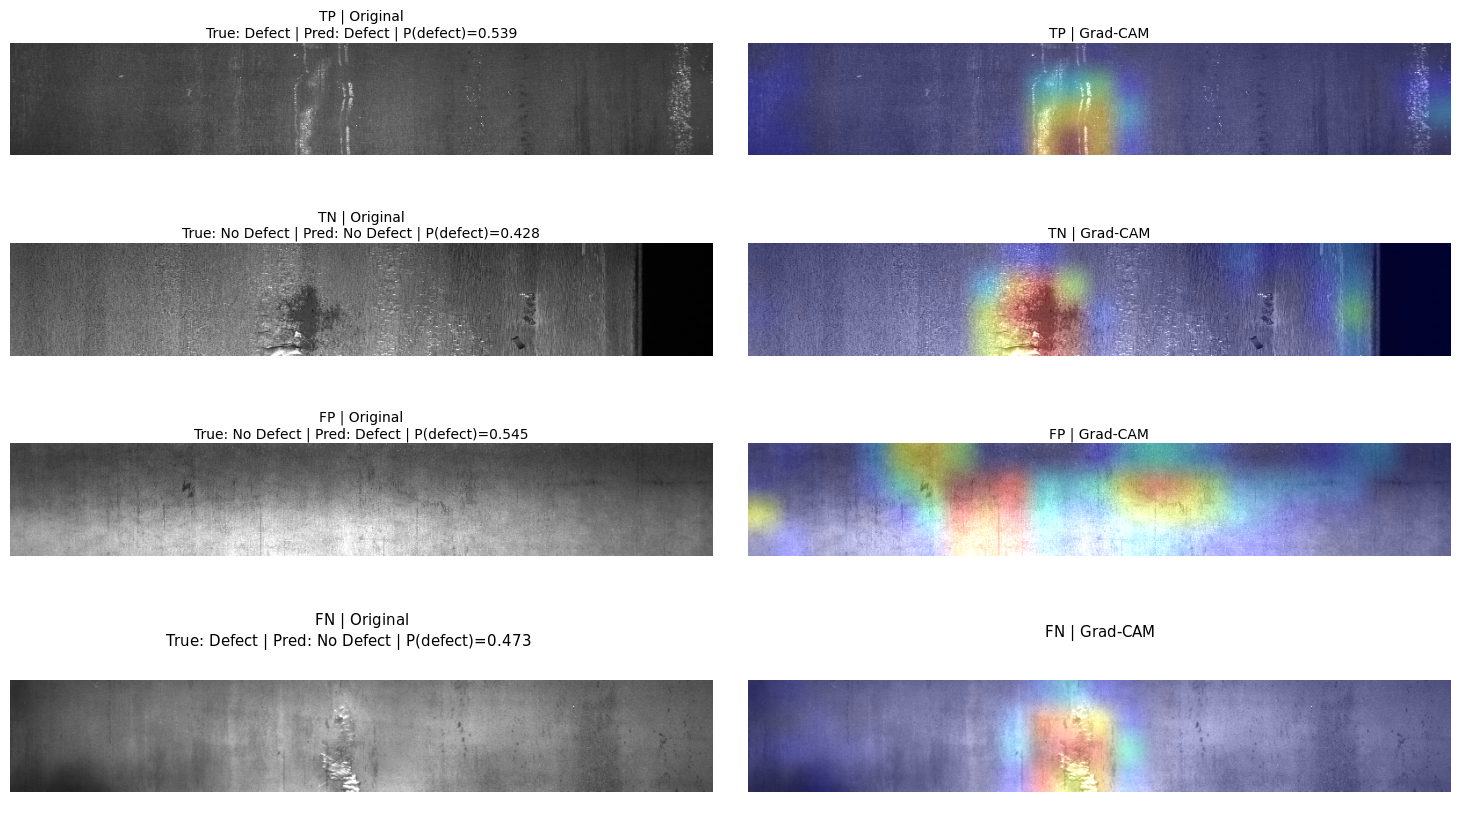

In [ ]:
def plot_gradcam_cases(cases, output_path):
    figure, axes = plt.subplots(
        len(cases),
        2,
        figsize=(15, len(cases) * 2.1),
        squeeze=False,
    )

    for row_index, (_, row) in enumerate(cases.iterrows()):
        original, overlay = overlay_gradcam(
            row["ImagePath"],
            make_gradcam_heatmap(get_image_array(row["ImagePath"])),
        )

        true_text = "Defect" if row["true_label"] == 1 else "No Defect"
        predicted_text = "Defect" if row["pred_label"] == 1 else "No Defect"

        axes[row_index, 0].imshow(original)
        axes[row_index, 0].axis("off")
        axes[row_index, 0].set_title(
            f'{row["case_type"]} | Original\n'
            f'True: {true_text} | Pred: {predicted_text} | '
            f'P(defect)={row["prob_defect"]:.3f}',
            fontsize=10,
            pad=4,
        )

        axes[row_index, 1].imshow(overlay)
        axes[row_index, 1].axis("off")
        axes[row_index, 1].set_title(
            f'{row["case_type"]} | Grad-CAM',
            fontsize=10,
            pad=4,
        )

    figure.subplots_adjust(
        left=0.02,
        right=0.98,
        top=0.98,
        bottom=0.03,
        wspace=0.05,
        hspace=0.75,
    )
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_gradcam_cases(
    final_selected,
    RESULTS_DIR / "borderline_cases_gradcam.png",
)


### Qualitative reading of the borderline cases

- **TP:** the highlighted area overlaps the central vertical surface
  irregularity, providing visually plausible evidence for the defect decision.
- **TN:** the heatmap emphasizes a bright, textured region, while the predicted
  defect probability remains below the threshold. This is a correct borderline
  decision.
- **FP:** highlighted areas are distributed across changes in brightness and
  texture rather than a single clear defect, suggesting sensitivity to surface
  appearance.
- **FN:** the heatmap overlaps the central anomaly even though the predicted
  defect probability remains below the threshold. This is precisely the type
  of image for which human review can be valuable.

These observations are qualitative. Grad-CAM indicates model sensitivity, but
does not prove that a highlighted region is a true defect or provide exact
defect boundaries. The per-image heatmap normalization also prevents direct
comparison of color intensity between cases.


## 6. High-confidence errors

A borderline-score review rule does not capture every failure. The next
analysis examines errors far from the threshold:

- high-confidence **false positives** have very large `P(defect)`;
- high-confidence **false negatives** have very small `P(defect)`.

Here, “high confidence” describes an extreme model output, not a guarantee that
the sigmoid probability is calibrated. These cases are operationally important
because the score alone gives no warning that the prediction may be wrong.


In [ ]:
false_positives = test_results[
    (test_results["true_label"] == 0)
    & (test_results["pred_label"] == 1)
].copy()

false_negatives = test_results[
    (test_results["true_label"] == 1)
    & (test_results["pred_label"] == 0)
].copy()

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))


False Positives: 39
False Negatives: 37


### Representative high-confidence errors

The thesis figure used two visually informative examples from each error type:

- FP — `5d046cb01.jpg`, `f1f00ee31.jpg`
- FN — `820c4f78c.jpg`, `5303447ca.jpg`

The selections come from the highest-confidence error groups; they are not
claimed to be statistically representative of every failure mode.


In [ ]:
EXTREME_ERROR_IDS = [
    "5d046cb01.jpg",
    "f1f00ee31.jpg",
    "820c4f78c.jpg",
    "5303447ca.jpg",
]

final_extreme_errors = (
    test_results.set_index("ImageId")
    .loc[EXTREME_ERROR_IDS]
    .reset_index()
)
final_extreme_errors["case_type"] = final_extreme_errors.apply(case_type, axis=1)

final_extreme_errors[
    ["ImageId", "case_type", "true_label", "pred_label", "prob_defect"]
]


ImageId case_type  true_label  pred_label  prob_defect
0  5d046cb01.jpg        FP           0           1     0.999519
1  f1f00ee31.jpg        FP           0           1     0.989909
2  820c4f78c.jpg        FN           1           0     0.004523
3  5303447ca.jpg        FN           1           0     0.015779

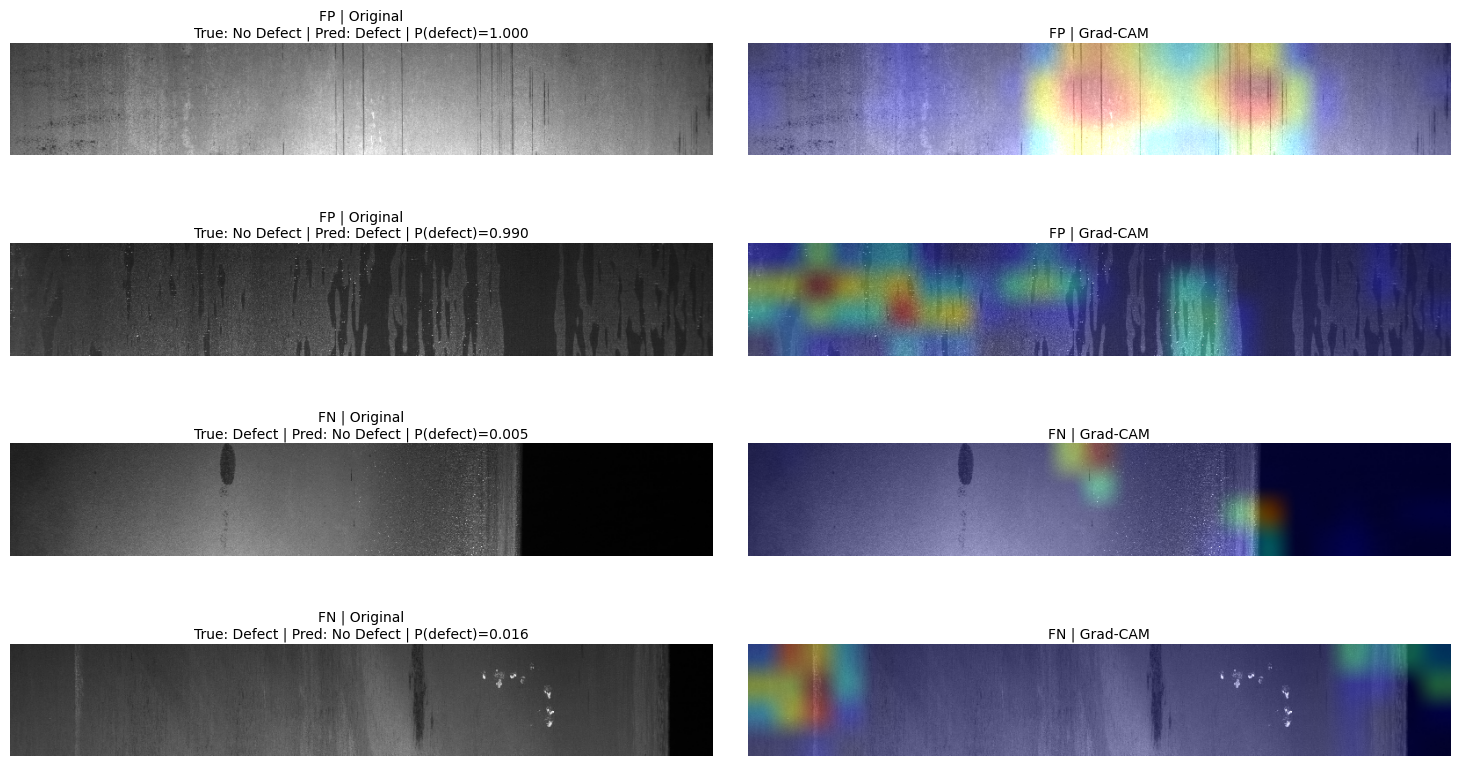

In [ ]:
plot_gradcam_cases(
    final_extreme_errors,
    RESULTS_DIR / "high_confidence_errors_gradcam.png",
)


### Qualitative reading of the high-confidence errors

- In the two **false positives**, the heatmaps concentrate on vertical streaks,
  dark bands, and broad texture changes. According to the dataset labels, these
  are non-defective surfaces, so the maps suggest that the model has learned
  defect-like visual cues that are not sufficiently specific.
- In the two **false negatives**, the highlighted areas are partial or displaced
  relative to visible local irregularities. The model nevertheless assigns very
  low `P(defect)` despite the positive labels.

The examples show why high confidence should not be interpreted as guaranteed
reliability. A borderline-score escalation rule alone would miss these
failures. Because the maps are normalized separately, their color intensity
must not be used to rank the strength of evidence across images.


## 7. Main findings

For the thesis checkpoint:

- only **35 of 1,886 test images (1.86%)** fall inside the `0.40–0.60` review
  band;
- the band contains **13 TN, 10 TP, 6 FP, and 6 FN** cases;
- **12 of the 35 borderline predictions (34.3%)** are incorrect;
- the full test set contains **76 errors** (39 FP and 37 FN), so the narrow
  review band captures **12/76 = 15.8%** of all errors while sending only 1.86%
  of images for review.

This makes threshold-based review useful, but incomplete. A practical inspection
system would benefit from combining borderline-score routing with:

1. periodic audits of high-confidence predictions;
2. Grad-CAM or another explanation for difficult cases;
3. monitoring for recurring texture, illumination, and edge-related failure
   patterns;
4. human feedback that can guide data curation and model improvement.

The analysis is a qualitative XAI case study. It does not evaluate localization
accuracy against segmentation masks, calibrate the classifier probabilities,
compare heatmap magnitude across images, or establish a production-ready review
threshold. The numerical findings belong specifically to the thesis checkpoint.

### Reference

Grad-CAM: Selvaraju et al., “Grad-CAM: Visual Explanations from Deep Networks
via Gradient-Based Localization,” ICCV 2017.
